# Adult Dataset: Experiment Results Analysis

This notebook loads the `.npy` result files from the Adult dataset experiments, aggregates the metrics across different random seeds, and generates summary tables and plots.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display, Markdown

# --- Configuration ---
RESULTS_DIR = './results/Adult/'
SEEDS = [6, 12, 13, 523, 972394]

# Define the experiments and their human-readable names
EXPERIMENTS = {
    'Baselines': [
        ('MAP', 'map_baseline'),
        ('LA', 'laplace_ll_baseline'),
        ('LA*', 'laplace_star_baseline'),
        ('Subspace LA', 'subspace_baseline'),
        ('SWAG-Laplace', 'swag_laplace_baseline'),
    ],
    'Domain Shift': [
        ('Shift: Male-to-Female', 'shift_male_to_female'),
        ('Shift: Female-to-Male', 'shift_female_to_male'),
    ],
    'Noise Intensity': [
        ('Noise: 0.1', 'noise_0.1'),
        ('Noise: 0.25', 'noise_0.25'),
        ('Noise: 0.5', 'noise_0.5'),
        ('Noise: 0.75', 'noise_0.75'),
        ('Noise: 1.0', 'noise_1.0'),
    ]
}

In [2]:
def get_calib(pys, y_true, M=15):
    """
    Calculate ECE. Assumes pys are probabilities and y_true are integer labels.
    """
    pys, y_true = np.array(pys), np.array(y_true)
    preds = np.argmax(pys, axis=1)
    confs = np.max(pys, axis=1)

    # Bin confidences
    bins = np.linspace(0, 1, M + 1)
    bin_lowers = bins[:-1]
    bin_uppers = bins[1:]

    ece = 0.0
    for i in range(M):
        in_bin = (confs > bin_lowers[i]) & (confs <= bin_uppers[i])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(preds[in_bin] == y_true[in_bin])
            avg_confidence_in_bin = np.mean(confs[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

def load_and_aggregate_results():
    """
    Loads all .npy result files, groups them by experiment,
    and computes the mean and standard deviation of metrics across seeds.
    """
    aggregated_results = dict()

    for category, experiments in EXPERIMENTS.items():
        for display_name, file_prefix in experiments:
            experiment_metrics = defaultdict(list)

            for seed in SEEDS:
                filename = f"{file_prefix}_seed{seed}.npy"
                file_path = os.path.join(RESULTS_DIR, filename)

                if os.path.exists(file_path):
                    try:
                        raw_data = np.load(file_path, allow_pickle=True)
                        metrics = raw_data[0]
                        experiment_metrics['Accuracy'].append(metrics.get('acc', np.nan))
                        experiment_metrics['NLL'].append(metrics.get('nll', np.nan))

                        # ECE needs probabilities and true labels, which are not saved in the file.
                        # We will skip ECE calculation for now. If you save `all_y_prob` and `all_y_true`
                        # you can calculate it here.
                        experiment_metrics['ECE'].append(metrics.get('ece', np.nan))

                    except Exception as e:
                        print(f"Warning: Could not load or process {filename}. Error: {e}")
                else:
                    # It's okay if some files are missing, just warn the user.
                    pass

            if experiment_metrics:
                summary = dict()
                for metric, values in experiment_metrics.items():
                    valid_values = [v for v in values if v is not None and not np.isnan(v)]
                    if valid_values:
                        summary[f'{metric}_mean'] = np.mean(valid_values)
                        summary[f'{metric}_std'] = np.std(valid_values)
                    else:
                        summary[f'{metric}_mean'] = np.nan
                        summary[f'{metric}_std'] = np.nan
                aggregated_results[(category, display_name)] = summary

    return aggregated_results

In [3]:
all_results = load_and_aggregate_results()

results_list = []
for (category, name), metrics in all_results.items():
    row = {'Category': category, 'Experiment': name, **metrics}
    results_list.append(row)

df = pd.DataFrame(results_list)
print("Results loaded and aggregated successfully.")
display(df.head())

Results loaded and aggregated successfully.


,Category,Experiment,Accuracy_mean,Accuracy_std,NLL_mean,NLL_std,ECE_mean,ECE_std
0,Baselines,MAP,0.765483,0.0,0.660595,0.000000e+00,0.235720,2.775558e-17
1,Baselines,LA,0.765483,0.0,0.663858,0.000000e+00,0.238872,0.000000e+00
2,Baselines,LA*,0.765483,0.0,0.663859,0.000000e+00,0.238873,2.775558e-17
3,Baselines,Subspace LA,0.765483,0.0,0.660616,0.000000e+00,0.235739,0.000000e+00
4,Baselines,SWAG-Laplace,0.855359,0.0,0.318213,3.814697e-07,0.030539,3.469447e-18


In [4]:
def format_and_display_table(results_df, title):
    """Formats and displays a DataFrame as a Markdown table in the notebook."""
    display(Markdown(f'### {title}'))
    if results_df.empty:
        print("No results to display for this category.")
        return

    # Format to 'mean ± std'
    for metric in ['Accuracy', 'NLL', 'ECE']:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        if mean_col in results_df.columns and std_col in results_df.columns:
            # Create a temporary column for formatted string
            results_df[metric] = results_df.apply(
                lambda row: f"{row[mean_col]:.4f} ± {row[std_col]:.4f}"
                if pd.notna(row[mean_col]) else "N/A",
                axis=1
            )

    display_cols = ['Experiment', 'Accuracy', 'NLL', 'ECE']
    # Filter out columns that don't exist in the df to prevent errors
    display_cols = [col for col in display_cols if col in results_df.columns]
    display(results_df[display_cols])

# Generate and display tables one by one
format_and_display_table(df[df['Category'] == 'Baselines'].copy(), "Baseline Method Comparison")
format_and_display_table(df[df['Category'] == 'Domain Shift'].copy(), "Domain Shift Results")
format_and_display_table(df[df['Category'] == 'Noise Intensity'].copy(), "Noise Intensity Results")

### Baseline Method Comparison

,Experiment,Accuracy,NLL,ECE
0,MAP,0.7655 ± 0.0000,0.6606 ± 0.0000,0.2357 ± 0.0000
1,LA,0.7655 ± 0.0000,0.6639 ± 0.0000,0.2389 ± 0.0000
2,LA*,0.7655 ± 0.0000,0.6639 ± 0.0000,0.2389 ± 0.0000
3,Subspace LA,0.7655 ± 0.0000,0.6606 ± 0.0000,0.2357 ± 0.0000
4,SWAG-Laplace,0.8554 ± 0.0000,0.3182 ± 0.0000,0.0305 ± 0.0000


### Domain Shift Results

,Experiment,Accuracy,NLL,ECE
5,Shift: Male-to-Female,0.7356 ± 0.0000,0.6834 ± 0.0000,0.2276 ± 0.0000
6,Shift: Female-to-Male,0.3038 ± 0.0000,0.7379 ± 0.0000,0.2472 ± 0.0000


### Noise Intensity Results

,Experiment,Accuracy,NLL,ECE
7,Noise: 0.1,0.7656 ± 0.0000,0.6639 ± 0.0000,0.2390 ± 0.0000
8,Noise: 0.25,0.7654 ± 0.0000,0.6641 ± 0.0000,0.2390 ± 0.0000
9,Noise: 0.5,0.7651 ± 0.0000,0.6649 ± 0.0000,0.2395 ± 0.0000
10,Noise: 0.75,0.7629 ± 0.0000,0.6661 ± 0.0000,0.2385 ± 0.0000
11,Noise: 1.0,0.7619 ± 0.0000,0.6676 ± 0.0000,0.2390 ± 0.0000


In [5]:
def format_and_display_table(results_df, title):
    """Formats and displays a DataFrame as a Markdown table in the notebook."""
    display(Markdown(f'### {title}'))
    if results_df.empty:
        print("No results to display for this category.")
        return

    # Format to 'mean ± std'
    for metric in ['Accuracy', 'NLL', 'ECE']:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        if mean_col in results_df.columns and std_col in results_df.columns:
            # Create a temporary column for formatted string
            results_df[metric] = results_df.apply(
                lambda row: f"{row[mean_col]:.4f} ± {row[std_col]:.4f}"
                if pd.notna(row[mean_col]) else "N/A",
                axis=1
            )

    display_cols = ['Experiment', 'Accuracy', 'NLL', 'ECE']
    # Filter out columns that don't exist in the df to prevent errors
    display_cols = [col for col in display_cols if col in results_df.columns]
    display(results_df[display_cols])

# Generate and display tables one by one
format_and_display_table(df[df['Category'] == 'Baselines'].copy(), "Baseline Method Comparison")
format_and_display_table(df[df['Category'] == 'Domain Shift'].copy(), "Domain Shift Results")
format_and_display_table(df[df['Category'] == 'Noise Intensity'].copy(), "Noise Intensity Results")

### Baseline Method Comparison

,Experiment,Accuracy,NLL,ECE
0,MAP,0.7655 ± 0.0000,0.6606 ± 0.0000,0.2357 ± 0.0000
1,LA,0.7655 ± 0.0000,0.6639 ± 0.0000,0.2389 ± 0.0000
2,LA*,0.7655 ± 0.0000,0.6639 ± 0.0000,0.2389 ± 0.0000
3,Subspace LA,0.7655 ± 0.0000,0.6606 ± 0.0000,0.2357 ± 0.0000
4,SWAG-Laplace,0.8554 ± 0.0000,0.3182 ± 0.0000,0.0305 ± 0.0000


### Domain Shift Results

,Experiment,Accuracy,NLL,ECE
5,Shift: Male-to-Female,0.7356 ± 0.0000,0.6834 ± 0.0000,0.2276 ± 0.0000
6,Shift: Female-to-Male,0.3038 ± 0.0000,0.7379 ± 0.0000,0.2472 ± 0.0000


### Noise Intensity Results

,Experiment,Accuracy,NLL,ECE
7,Noise: 0.1,0.7656 ± 0.0000,0.6639 ± 0.0000,0.2390 ± 0.0000
8,Noise: 0.25,0.7654 ± 0.0000,0.6641 ± 0.0000,0.2390 ± 0.0000
9,Noise: 0.5,0.7651 ± 0.0000,0.6649 ± 0.0000,0.2395 ± 0.0000
10,Noise: 0.75,0.7629 ± 0.0000,0.6661 ± 0.0000,0.2385 ± 0.0000
11,Noise: 1.0,0.7619 ± 0.0000,0.6676 ± 0.0000,0.2390 ± 0.0000


--- Creating Plots ---
Saved noise intensity plot to adult_noise_intensity_plot.png


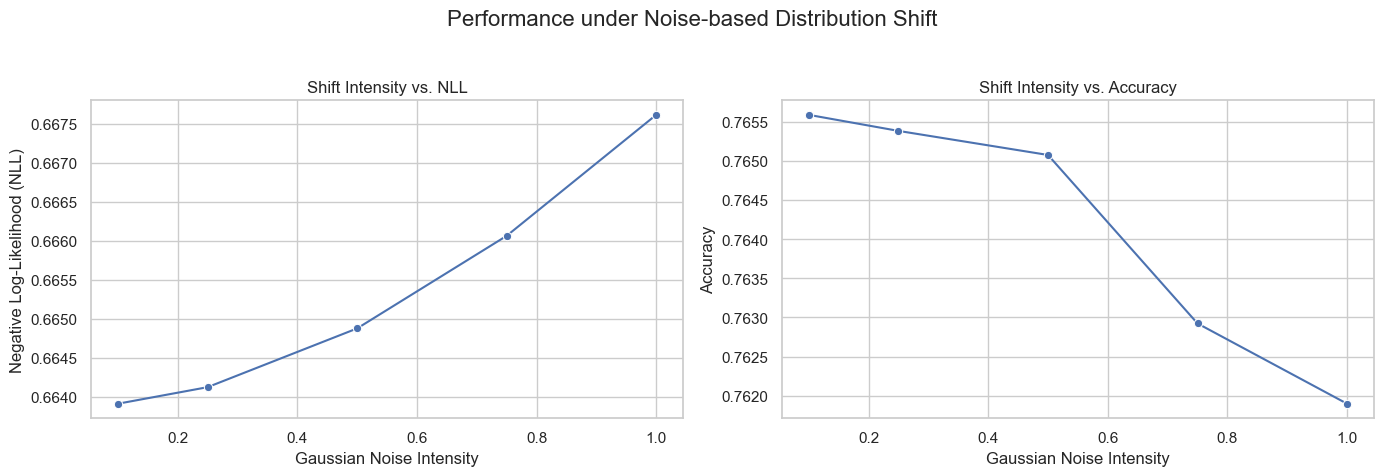

Saved domain shift plot to adult_domain_shift_plot.png


/var/folders/0n/wh_c5_xd26927bl2qb_trgnc0000gn/T/ipykernel_12628/3705167190.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_shift_df, x='Condition', y='Accuracy_mean', ax=ax1, palette='mako')
/var/folders/0n/wh_c5_xd26927bl2qb_trgnc0000gn/T/ipykernel_12628/3705167190.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_shift_df, x='Condition', y='NLL_mean', ax=ax2, palette='viridis')


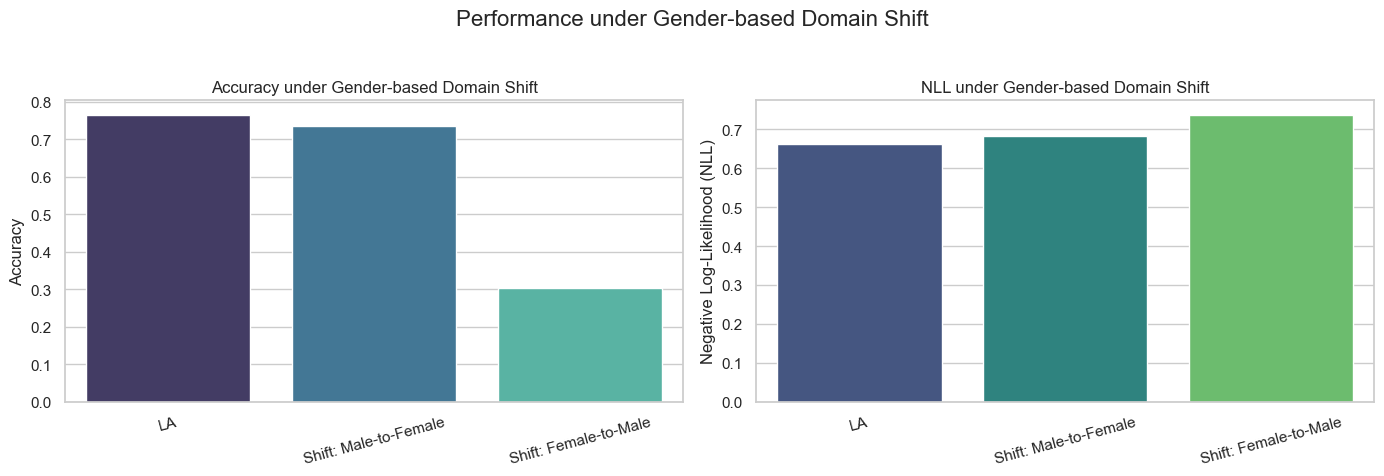

In [6]:
print("--- Creating Plots ---")
sns.set_theme(style="whitegrid")

# Filter for necessary data
noise_df = df[df['Category'] == 'Noise Intensity'].copy()
shift_df = df[df['Category'] == 'Domain Shift']
baseline_df = df[df['Category'] == 'Baselines']

# --- Plot 1: Noise Intensity ---
if not noise_df.empty:
    noise_df['Intensity'] = noise_df['Experiment'].str.extract(r'(\d+\.?\d*)').astype(float)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(data=noise_df, x='Intensity', y='NLL_mean', marker='o', ax=ax1)
    ax1.set_title('Shift Intensity vs. NLL')
    ax1.set_ylabel('Negative Log-Likelihood (NLL)')
    ax1.set_xlabel('Gaussian Noise Intensity')

    sns.lineplot(data=noise_df, x='Intensity', y='Accuracy_mean', marker='o', ax=ax2)
    ax2.set_title('Shift Intensity vs. Accuracy')
    ax2.set_ylabel('Accuracy')
    ax2.set_xlabel('Gaussian Noise Intensity')

    fig.suptitle('Performance under Noise-based Distribution Shift', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('adult_noise_intensity_plot.png')
    print("Saved noise intensity plot to adult_noise_intensity_plot.png")
    plt.show()

# --- Plot 2: Domain Shift ---
# Add baseline LA results to the shift_df for plotting comparison
plot_shift_df = pd.concat([
    baseline_df[baseline_df['Experiment'] == 'LA'],
    shift_df
]).rename(columns={'Experiment': 'Condition'})

if not plot_shift_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    sns.barplot(data=plot_shift_df, x='Condition', y='Accuracy_mean', ax=ax1, palette='mako')
    ax1.set_title('Accuracy under Gender-based Domain Shift')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=15)

    sns.barplot(data=plot_shift_df, x='Condition', y='NLL_mean', ax=ax2, palette='viridis')
    ax2.set_title('NLL under Gender-based Domain Shift')
    ax2.set_ylabel('Negative Log-Likelihood (NLL)')
    ax2.set_xlabel('')
    ax2.tick_params(axis='x', rotation=15)

    fig.suptitle('Performance under Gender-based Domain Shift', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('adult_domain_shift_plot.png')
    print("Saved domain shift plot to adult_domain_shift_plot.png")
    plt.show()